## 1) Setup

In [ ]:
from google.colab import auth

auth.authenticate_user()


In [ ]:
# Se necessário, instale as dependências (descomente na 1ª execução local)
# %pip install google-cloud-bigquery pandas matplotlib pyarrow db-dtypes

import os
import pandas as pd
import matplotlib.pyplot as plt


from google.cloud import bigquery

# Configurações do projeto/datasets
PROJECT_ID = "datathon-470123"     # <- ajuste se necessário
BRONZE = "bronze"
SILVER = "silver"


TABLE_APPLICANT = f"{PROJECT_ID}.{BRONZE}.tb_applicant"
TABLE_PROSPECT  = f"{PROJECT_ID}.{BRONZE}.tb_prospect"
TABLE_VAGA      = f"{PROJECT_ID}.{BRONZE}.tb_vaga"

# Autenticação:
# Para autenticar no Google Cloud em ambientes como o Google Colab, você pode usar o Application Default Credentials (ADC).
# Rode o seguinte comando em uma célula de código separada para autenticar:
# from google.colab import auth
# auth.authenticate_user()


client = bigquery.Client(project=PROJECT_ID)
def run_sql(sql: str) -> pd.DataFrame:
    """Executa uma query SQL no BigQuery e retorna DataFrame."""
    return client.query(sql).to_dataframe()

## 2) Inventário e qualidade de dados

In [ ]:

# 2.1) Contagem de linhas por tabela
sql_counts = f"""
SELECT 'tb_applicant' AS tabela, COUNT(*) AS n_linhas FROM `{TABLE_APPLICANT}`
UNION ALL
SELECT 'tb_prospect'  AS tabela, COUNT(*) AS n_linhas FROM `{TABLE_PROSPECT}`
UNION ALL
SELECT 'tb_vaga'      AS tabela, COUNT(*) AS n_linhas FROM `{TABLE_VAGA}`
"""
df_counts = run_sql(sql_counts)
df_counts


,tabela,n_linhas
0,tb_applicant,42482
1,tb_vaga,14081
2,tb_prospect,14222


In [ ]:
# 2.2) Amostra dos dados
df_app_sample = run_sql(f"SELECT * FROM `{TABLE_APPLICANT}` LIMIT 5")
df_pros_sample = run_sql(f"SELECT * FROM `{TABLE_PROSPECT}` LIMIT 5")
df_vaga_sample = run_sql(f"SELECT * FROM `{TABLE_VAGA}` LIMIT 5")

display(df_app_sample)
display(df_pros_sample)
display(df_vaga_sample)

,cv_en,cv_pt,informacoes_pessoais,formacao_e_idiomas,informacoes_profissionais,cargo_atual,infos_basicas,job_id
0,,assistente administrativo\n\n\nsantosbatista\n...,"{'url_linkedin': '', 'pcd': '', 'facebook': ''...","{'ano_conclusao': None, 'cursos': None, 'nivel...","{'experiencias': None, 'qualificacoes': None, ...","{'nome_superior_imediato': None, 'unidade': No...","{'codigo_profissional': 31000, 'data_atualizac...",31000
1,,formação acadêmica\nensino médio (2º grau) em ...,"{'url_linkedin': '', 'pcd': 'Não', 'facebook':...","{'ano_conclusao': None, 'cursos': None, 'nivel...","{'experiencias': None, 'qualificacoes': None, ...","{'nome_superior_imediato': None, 'unidade': No...","{'codigo_profissional': 31001, 'data_atualizac...",31001
2,,objetivo: área administrativa | financeira\n\n...,"{'url_linkedin': '', 'pcd': 'Não', 'facebook':...","{'ano_conclusao': 2012, 'cursos': 'Administraç...","{'experiencias': None, 'qualificacoes': None, ...","{'nome_superior_imediato': None, 'unidade': No...","{'codigo_profissional': 31002, 'data_atualizac...",31002
3,,formação\nensino médio completo\ninformática i...,"{'url_linkedin': '', 'pcd': 'Não', 'facebook':...","{'ano_conclusao': None, 'cursos': None, 'nivel...","{'experiencias': None, 'qualificacoes': None, ...","{'nome_superior_imediato': None, 'unidade': No...","{'codigo_profissional': 31003, 'data_atualizac...",31003
4,,última atualização em 09/11/2021\n­ sp\n\nensi...,"{'url_linkedin': '', 'pcd': '', 'facebook': ''...","{'ano_conclusao': None, 'cursos': None, 'nivel...","{'experiencias': None, 'qualificacoes': None, ...","{'nome_superior_imediato': None, 'unidade': No...","{'codigo_profissional': 31004, 'data_atualizac...",31004


,prospects,modalidade,titulo,job_id
0,"[{'comentario': 'Encaminhado para - PJ R$ 72,...",,CONSULTOR CONTROL M,4530
1,"[{'comentario': 'Data de Inicio: 12/04/2021', ...",,2021-2607395-PeopleSoft Application Engine-Dom...,4531
2,[],,,4532
3,"[{'comentario': '', 'data_candidatura': 2021-0...",,2021-2605708-Microfocus Application Life Cycle...,4533
4,[{'comentario': 'Aguardando confirmação de ini...,,2021-2605711-Microfocus QTP - UFT Automation T...,4534


,perfil_vaga,informacoes_basicas,beneficios,job_id
0,{'habilidades_comportamentais_necessarias': No...,"{'data_final': '21-12-2023', 'telefone': None,...","{'valor_compra_2': '', 'valor_compra_1': 'Fech...",11669
1,{'habilidades_comportamentais_necessarias': No...,"{'data_final': None, 'telefone': None, 'nome':...","{'valor_compra_2': '', 'valor_compra_1': '7k c...",3985
2,{'habilidades_comportamentais_necessarias': No...,"{'data_final': None, 'telefone': None, 'nome':...","{'valor_compra_2': '', 'valor_compra_1': '7k c...",3984
3,{'habilidades_comportamentais_necessarias': No...,"{'data_final': '00-00-0000', 'telefone': None,...","{'valor_compra_2': '', 'valor_compra_1': 'hora...",6615
4,{'habilidades_comportamentais_necessarias': 'P...,"{'data_final': '30-11-0001', 'telefone': None,...","{'valor_compra_2': '', 'valor_compra_1': '00,0...",6572


## 3) Views de Flatten

In [ ]:
# Criação das views (idempotente)
run_sql(f'''
CREATE OR REPLACE VIEW `{PROJECT_ID}.{SILVER}.vw_prospects_flat` AS
SELECT
  p.job_id,
  pr.codigo                AS codigo_profissional,
  pr.nome                  AS nome_prospect,
  pr.situacao_candidado,
  pr.recrutador,
  pr.comentario,
  pr.data_candidatura,
  pr.ultima_atualizacao
FROM `{PROJECT_ID}.{BRONZE}.tb_prospect` p,
UNNEST(p.prospects) AS pr
''');

run_sql(f'''
CREATE OR REPLACE VIEW `{PROJECT_ID}.{SILVER}.vw_applicant_flat` AS
SELECT
  a.job_id,
  a.infos_basicas.codigo_profissional     AS codigo_profissional,
  a.infos_basicas.nome                    AS nome_candidato,
  a.infos_basicas.email                   AS email_candidato,
  a.infos_basicas.local                   AS local_candidato,
  a.formacao_e_idiomas.nivel_ingles       AS nivel_ingles_cand,
  a.formacao_e_idiomas.nivel_espanhol     AS nivel_espanhol_cand,
  a.formacao_e_idiomas.nivel_academico    AS nivel_academico_cand,
  a.informacoes_profissionais.conhecimentos_tecnicos AS conhecimentos_tecnicos,
  a.informacoes_profissionais.experiencias          AS experiencias,
  a.informacoes_profissionais.nivel_profissional    AS nivel_profissional_cand,
  a.cargo_atual.cargo_atual               AS cargo_atual_cand,
  a.cv_pt, a.cv_en
FROM `{PROJECT_ID}.{BRONZE}.tb_applicant` a
''');

run_sql(f'''
CREATE OR REPLACE VIEW `{PROJECT_ID}.{SILVER}.vw_vagas_flat` AS
SELECT
  v.job_id,
  v.informacoes_basicas.titulo_vaga,
  v.informacoes_basicas.cliente,
  v.informacoes_basicas.tipo_contratacao,
  v.informacoes_basicas.analista_responsavel,
  v.informacoes_basicas.prioridade_vaga,
  v.informacoes_basicas.data_inicial,
  v.informacoes_basicas.data_final,
  v.perfil_vaga.nivel_ingles              AS nivel_ingles_req,
  v.perfil_vaga.nivel_espanhol            AS nivel_espanhol_req,
  v.perfil_vaga.nivel_academico           AS nivel_academico_req,
  v.perfil_vaga.`nivel profissional`      AS nivel_profissional_req,
  v.perfil_vaga.principais_atividades     AS principais_atividades,
  v.perfil_vaga.competencia_tecnicas_e_comportamentais AS competencias_tecnicas
FROM `{PROJECT_ID}.{BRONZE}.tb_vaga` v
''');

print("Views criadas/atualizadas: vw_prospects_flat, vw_applicant_flat, vw_vagas_flat")


Views criadas/atualizadas: vw_prospects_flat, vw_applicant_flat, vw_vagas_flat


## 4) Dataset Unificado (vaga × prospect × applicant)

In [ ]:
q_merge = f'''
WITH pros_last AS (
  SELECT
    job_id,
    codigo_profissional,
    ANY_VALUE(nome_prospect) AS nome_prospect,
    ANY_VALUE(recrutador)    AS recrutador,
    ANY_VALUE(comentario)    AS comentario,
    MAX(ultima_atualizacao)  AS dt_last_update,
    ARRAY_AGG(situacao_candidado IGNORE NULLS ORDER BY ultima_atualizacao DESC LIMIT 1)[OFFSET(0)] AS situacao_candidado_last
  FROM `{PROJECT_ID}.{SILVER}.vw_prospects_flat`
  GROUP BY 1,2
)
SELECT
  v.job_id, v.titulo_vaga, v.cliente, v.tipo_contratacao, v.analista_responsavel, v.prioridade_vaga,
  v.data_inicial, v.data_final,
  v.competencias_tecnicas, v.principais_atividades, a.cv_pt, a.cv_en,
  v.nivel_ingles_req, v.nivel_espanhol_req, v.nivel_academico_req, v.nivel_profissional_req,
  a.codigo_profissional, a.nome_candidato, a.email_candidato, a.local_candidato,
  a.nivel_ingles_cand, a.nivel_espanhol_cand, a.nivel_academico_cand, a.nivel_profissional_cand,
  a.conhecimentos_tecnicos, a.experiencias, a.cargo_atual_cand,
  p.situacao_candidado_last AS situacao_candidado,
  p.recrutador, p.comentario, p.dt_last_update
FROM `{PROJECT_ID}.{SILVER}.vw_vagas_flat` v
LEFT JOIN pros_last p
  ON p.job_id = v.job_id
LEFT JOIN `{PROJECT_ID}.{SILVER}.vw_applicant_flat` a
  ON a.codigo_profissional = p.codigo_profissional
'''
df = run_sql(q_merge)
df.head()

,job_id,titulo_vaga,cliente,tipo_contratacao,analista_responsavel,prioridade_vaga,data_inicial,data_final,competencias_tecnicas,principais_atividades,...,nivel_espanhol_cand,nivel_academico_cand,nivel_profissional_cand,conhecimentos_tecnicos,experiencias,cargo_atual_cand,situacao_candidado,recrutador,comentario,dt_last_update
0,11669,Desenvolvedor Web,Acevedo Inc,Hunting,Laura Pacheco,Alta: Alta complexidade 3 a 5 dias,21-08-2023,21-12-2023,Cargo: Desenvolvedor Web\nSkills: typescript /...,Cargo: Desenvolvedor Web\nSkills: typescript /...,...,None,None,None,None,None,None,Entrevista Técnica,Clara Rios,Entrevista agendada para 04/10/2023,2023-10-03
1,11669,Desenvolvedor Web,Acevedo Inc,Hunting,Laura Pacheco,Alta: Alta complexidade 3 a 5 dias,21-08-2023,21-12-2023,Cargo: Desenvolvedor Web\nSkills: typescript /...,Cargo: Desenvolvedor Web\nSkills: typescript /...,...,None,None,None,None,None,None,Desistiu,Laura Pacheco,Candidato não possui mais interesse no process...,2023-09-18
2,11669,Desenvolvedor Web,Acevedo Inc,Hunting,Laura Pacheco,Alta: Alta complexidade 3 a 5 dias,21-08-2023,21-12-2023,Cargo: Desenvolvedor Web\nSkills: typescript /...,Cargo: Desenvolvedor Web\nSkills: typescript /...,...,None,None,None,None,None,None,Encaminhado ao Requisitante,Clara Rios,,2023-08-25
3,11669,Desenvolvedor Web,Acevedo Inc,Hunting,Laura Pacheco,Alta: Alta complexidade 3 a 5 dias,21-08-2023,21-12-2023,Cargo: Desenvolvedor Web\nSkills: typescript /...,Cargo: Desenvolvedor Web\nSkills: typescript /...,...,None,None,None,None,None,None,Desistiu,Laura Pacheco,Candidato não tem mais interesse em continuar ...,2023-09-18
4,11669,Desenvolvedor Web,Acevedo Inc,Hunting,Laura Pacheco,Alta: Alta complexidade 3 a 5 dias,21-08-2023,21-12-2023,Cargo: Desenvolvedor Web\nSkills: typescript /...,Cargo: Desenvolvedor Web\nSkills: typescript /...,...,None,None,None,None,None,None,Prospect,Clara Rios,,2023-08-24


## 5) Profiling básico

In [ ]:

print("Shape:", df.shape)
display(df.sample(5, random_state=42))
df.describe(include='all').T.head(30)


Shape: (56539, 31)


,job_id,titulo_vaga,cliente,tipo_contratacao,analista_responsavel,prioridade_vaga,data_inicial,data_final,competencias_tecnicas,principais_atividades,...,nivel_espanhol_cand,nivel_academico_cand,nivel_profissional_cand,conhecimentos_tecnicos,experiencias,cargo_atual_cand,situacao_candidado,recrutador,comentario,dt_last_update
35938,9247,UX,"Miller, Tran and Chang","CLT Full, PJ/Autônomo",Emanuella Campos,Alta: Alta complexidade 3 a 5 dias,None,None,perfi ja enviado,perfil ja enviado,...,,,,,None,None,Prospect,Maria Clara Pires,,2022-05-05
41825,4427,Dev Jr -RE-312788,"Morris, Moran and Dodson",CLT Full,Ana Camargo,,None,None,Conhecimento da ferramenta Skelta/Intelatrac d...,Dev Jr\n\n• Mandatórios\n\nSQL Server (Develop...,...,Intermediário,Ensino Superior Completo,,"HTML, CSS, JAVASCRIPT, PHP, PYTHON, JQUERY, BO...",None,None,Inscrito,Caroline Machado,,NaT
17617,6831,Desenvolvedor Java - (Sênior),Barnes-Woods,PJ/Autônomo,Lunna Fonseca,Alta: Alta complexidade 3 a 5 dias,None,None,Experiência em desenvolvimento em Java / J2EE ...,Conhecimento das técnicas TDD e BDD\n\nNível S...,...,,,,,None,None,Não Aprovado pelo RH,Lunna Fonseca,"Perfil Junior, também nesse momento não está a...",2021-09-27
7340,12041,SAP MM - SV-116,Morrison Ltd,PJ/Autônomo,Emanuelly Vieira,Alta: Alta complexidade 3 a 5 dias,19-12-2023,30-04-2024,Consultor MM para fazer conversão da TAXNRJ pa...,Conhecimento especifico: TAXBRA,...,None,None,None,None,None,None,Encaminhado ao Requisitante,Emanuelly Vieira,,2023-12-06
50378,2556,Java - 10237618,Nelson-Page,CLT Full,Helena Barros,Alta: Alta complexidade 3 a 5 dias,None,None,Profissional com experiência minima de 3 anos ...,Profissional com experiência minima de 3 anos ...,...,,,,,None,None,Desistiu,Dra. Luara Siqueira,Só avalia propostas PJ R$ 90/h,2020-06-22


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,56539.0,<NA>,<NA>,<NA>,7784.164842,3895.949775,2.0,4438.0,8105.0,11179.0,14222.0
titulo_vaga,56539,12452,SAP SD,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cliente,56539,112,Nelson-Page,8145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_contratacao,56539,40,PJ/Autônomo,19089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
analista_responsavel,56539,63,Srta. Bella Ferreira,5433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prioridade_vaga,56539,4,Alta: Alta complexidade 3 a 5 dias,37287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_inicial,14172,848,30-11-0001,823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_final,14172,1244,30-11-0001,829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
competencias_tecnicas,56539,11552,.,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
principais_atividades,56539,11710,"Recebimento, separação e armazenamento de prod...",197,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 5.1) Nulos por coluna

In [ ]:

nulls = df.isna().mean().sort_values(ascending=False).to_frame('%_nulls')
nulls.head(30)


,%_nulls
experiencias,0.983587
cargo_atual_cand,0.983587
data_inicial,0.749341
data_final,0.749341
nivel_profissional_cand,0.202833
local_candidato,0.202833
email_candidato,0.202833
nivel_ingles_cand,0.202833
nivel_espanhol_cand,0.202833
nome_candidato,0.202833


### 5.2) Chaves e duplicidades

In [ ]:

# Expectativa: (job_id, codigo_profissional) deve ser único após o agrupamento em pros_last
dups = df.duplicated(subset=["job_id","codigo_profissional"]).sum()
print("Duplicados (job_id, codigo_profissional):", dups)

Duplicados (job_id, codigo_profissional): 5751


## 6) Funnel — Situação do candidato

In [ ]:

funnel = (
    df.assign(alvo=lambda d: d["situacao_candidado"].str.lower().str.normalize('NFKD').str.encode('ascii','ignore').str.decode('ascii'))
      .assign(contratado=lambda d: d["alvo"].isin(['aprovado','admitido','hired']).astype(int))
)
funnel['situacao_candidado'].fillna('NA', inplace=True)
display(funnel['situacao_candidado'].value_counts(dropna=False).head(20))
print("\nTaxa de contratação (proxy):", f"{funnel['contratado'].mean():.2%}")


/tmp/ipython-input-799819438.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  funnel['situacao_candidado'].fillna('NA', inplace=True)


,count
situacao_candidado,
Prospect,20005
Encaminhado ao Requisitante,16120
Inscrito,3978
Não Aprovado pelo Cliente,3489
NA,2804
Contratado pela Decision,2757
Desistiu,2349
Não Aprovado pelo RH,1765
Não Aprovado pelo Requisitante,765



Taxa de contratação (proxy): 0.37%


## 7) Requisitos da vaga × perfil do candidato

In [ ]:
import re
def norm_txt(s):
    if s is None: return None
    s = str(s).strip().lower()
    m = re.search(r'(basico|basica|intermediario|intermediaria|avancado|fluente|nativo)', s)
    return m.group(1) if m else s

comp = (
    df.assign(
        ing_req=df['nivel_ingles_req'].apply(norm_txt),
        ing_cand=df['nivel_ingles_cand'].apply(norm_txt),
        esp_req=df['nivel_espanhol_req'].apply(norm_txt),
        esp_cand=df['nivel_espanhol_cand'].apply(norm_txt),
    )
)

for col in ['ing_req','ing_cand','esp_req','esp_cand']:
    print(f"Top valores — {col}")
    display(comp[col].value_counts(dropna=False).head(10))

# Matriz simples: requisito x candidato (inglês)
pd.crosstab(comp['ing_req'], comp['ing_cand']).head(10)


Top valores — ing_req


,count
ing_req,
básico,20042
nenhum,13192
avançado,10539
fluente,6357
intermediário,5612
técnico,797


Top valores — ing_cand


,count
ing_cand,
,33667
None,11468
intermediário,3947
avançado,3162
básico,2775
fluente,1190
nenhum,330


Top valores — esp_req


,count
esp_req,
nenhum,24966
básico,23489
,5007
avançado,1092
intermediário,1029
fluente,899
técnico,57


Top valores — esp_cand


,count
esp_cand,
,33970
None,11468
básico,5021
nenhum,2691
intermediário,1961
avançado,769
fluente,659


ing_cand,,avançado,básico,fluente,intermediário,nenhum
ing_req,,,,,,
avançado,6801,794,266,326,538,11
básico,10838,892,1187,274,1542,180
fluente,3800,469,134,239,286,5
intermediário,3315,316,295,106,504,25
nenhum,8428,644,836,224,991,107
técnico,485,47,57,21,86,2


In [ ]:

def txt_len(s):
    return 0 if pd.isna(s) else len(str(s))

text_cols = {
    "competencias_tecnicas": df["competencias_tecnicas"],
    "principais_atividades": df["principais_atividades"],
    "conhecimentos_tecnicos": df["conhecimentos_tecnicos"],
    "experiencias": df["experiencias"],
    "cv_pt": df["cv_pt"],
}

lens = {k: v.map(txt_len).describe()[['count','mean','50%','max']] for k,v in text_cols.items()}
pd.DataFrame(lens)


,competencias_tecnicas,principais_atividades,conhecimentos_tecnicos,experiencias,cv_pt
count,56539.000000,56539.000000,56539.000000,56539.0,56539.000000
mean,397.708272,434.655035,53.498541,0.0,4038.578574
50%,233.000000,275.000000,0.000000,0.0,2900.000000
max,5835.000000,6114.000000,10321.000000,0.0,60178.000000


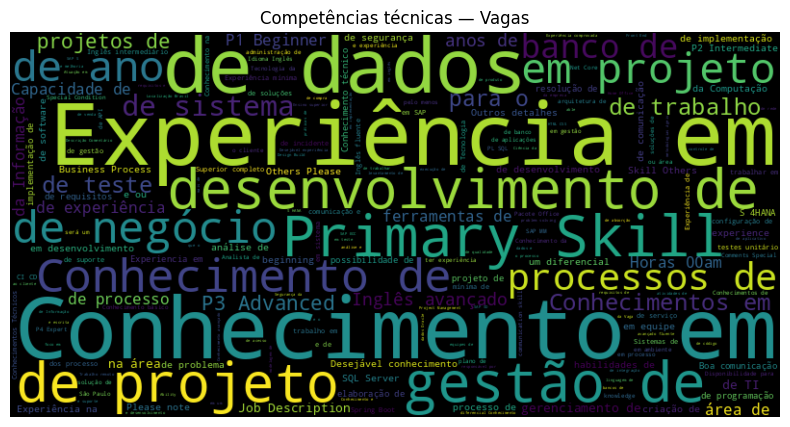

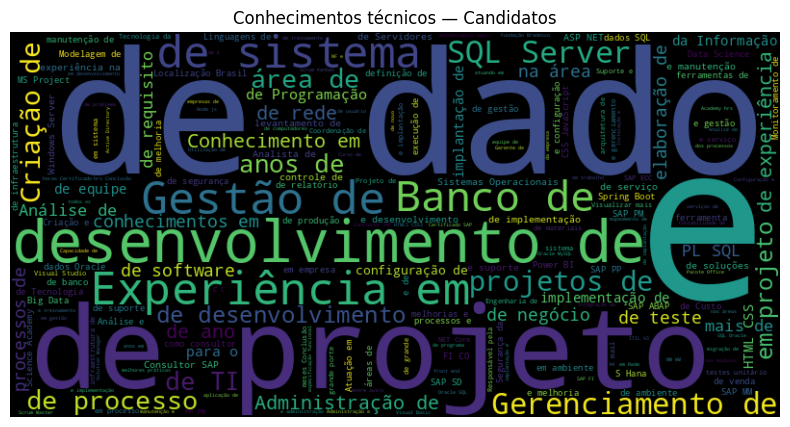

In [ ]:
from wordcloud import WordCloud  # opcional

# WordCloud rápida (opcional) para "competencias_tecnicas" de vagas e "conhecimentos_tecnicos" de candidatos
def wc(series, title):
    txt = " ".join([str(x) for x in series.dropna().values])
    if not txt.strip():
        print("Sem texto para", title); return
    wc = WordCloud(width=800, height=400).generate(txt)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off"); plt.title(title); plt.show()

try:
    wc(df['competencias_tecnicas'], "Competências técnicas — Vagas")
    wc(df['conhecimentos_tecnicos'], "Conhecimentos técnicos — Candidatos")
except Exception as e:
    print("WordCloud opcional:", e)
